In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd()))
from utils import DATA_DIR, ROOT_DIR

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataloader import get_nd_array, get_slice
from download.hf import pull_predictions_from_hf

In [105]:
# Load benchmark-level results
local_path = pull_predictions_from_hf("allenai/ladder-evals", "benchmarks")
df_benchmarks = pd.read_parquet(local_path)

In [104]:
local_path = pull_predictions_from_hf("allenai/ladder-evals", "instances")

In [4]:
# Choose a subset of columns to save on memory
COLS = ['step', 'model', 'task', 'mix', 'size', 'token_ratio', 'native_id']
COLS += ['acc_per_char', 'logits_per_byte', 'correct_choice', 'logits_per_char_corr', 'logits_per_byte_corr'] # accuracy benchmarks
COLS += ['exact_match', 'f1'] # generation benchmarks
COLS += ['pass_at_1', 'pass_at_10'] # code benchmarks

COLS = ['step', 'model', 'task', 'mix', 'native_id']
COLS += ['acc_per_char', 'logits_per_byte', 'logits_per_byte_corr'] # accuracy benchmarks

# Load instance-level evaluations
df = pd.read_parquet(local_path, columns=COLS)
print(f'Loaded {len(df):,} instance results')

Loaded 135,360,885 instance results


In [171]:
olmes = ['arc_challenge', 'arc_easy', 'boolq', 'csqa', 'hellaswag', 'openbookqa', 'piqa', 'socialiqa', 'winogrande']
selected_tasks = olmes

In [172]:
step_names, scores = get_nd_array(
    df,
    col=["step"], # the dimensions of the array
    metric="acc_per_char", # the entries of the array
    task=selected_tasks,
    model="peteish-moreeval-1B-5xC",
    mix=None,
    step=None,
    sorted=True
)

print(f'Results on {len(step_names)} intermediate checkpoints:')
print(scores[:20])
print(scores.shape)

Results on 164 intermediate checkpoints:
[[1. 0. 0. ... 1. 1. 1.]
 [0. 0. 0. ... 1. 1. 1.]
 [1. 0. 0. ... 1. 1. 1.]
 ...
 [1. 1. 0. ... 1. 1. 1.]
 [1. 0. 0. ... 1. 1. 1.]
 [1. 0. 0. ... 1. 1. 1.]]
(164, 23168)


In [173]:
step_names = [str(int(i)) for i in step_names]
instance_names = [str(i) for i in range(scores.shape[1])]

### Train IRT model

In [174]:
from irt_utils.irt_train import train

# ~/miniconda3/envs/metaeval_pyirt/lib/python3.10/site-packages/py_irt
irt_params = train(
    model_type="2pl", # 1pl, 2pl, 3pl, 4pl, amortized_1pl
    predictions=scores.T, 
    model_names=step_names,
    instance_names=instance_names,
    priors="hierarchical", # vague, hierarchical
    # epochs=500,
    epochs=1000,
    hidden=30,
    # lr=0.1,
    lr=0.4,
    # lr_decay=0.995,
    lr_decay=0.999,
    device='cpu', # cpu, cuda, mps
    quiet=True
)

[11:18:48] Vocab size: None                                                                          ]8;id=61538;file:///Users/dhei/miniconda3/envs/metaeval_pyirt/lib/python3.10/site-packages/py_irt/training.py\training.py]8;;\:]8;id=301642;file:///Users/dhei/miniconda3/envs/metaeval_pyirt/lib/python3.10/site-packages/py_irt/training.py#90\90]8;;\

[11:18:49] args: {'device': 'cpu', 'num_items': 23168, 'num_subjects': 164}                         ]8;id=515072;file:///Users/dhei/miniconda3/envs/metaeval_pyirt/lib/python3.10/site-packages/py_irt/training.py\training.py]8;;\:]8;id=833607;file:///Users/dhei/miniconda3/envs/metaeval_pyirt/lib/python3.10/site-packages/py_irt/training.py#134\134]8;;\

           Parsed Model Args: {'device': 'cpu', 'num_items': 23168, 'num_subjects': 164, 'priors':  ]8;id=35678;file:///Users/dhei/miniconda3/envs/metaeval_pyirt/lib/python3.10/site-packages/py_irt/training.py\training.py]8;;\:]8;id=877015;file:///Users/dhei/miniconda3/envs/metaeval_pyirt/lib/python3.10/site-packages/py_irt/training.py#147\147]8;;\
           'hierarchical', 'dropout': 0.5, 'hidden': 30, 'vocab_size': None}                                       

Output()

Training Pyro IRT Model for 1000 epochs

torch.Size([3799552]) torch.Size([3799552])


In [175]:
# We exctract the learned ability parameters
ability_dict = dict(zip(irt_params["subject_ids"].values(), irt_params["ability"]))

# Top five models according to IRT model
print(sorted(ability_dict.items(), key=lambda x: x[1], reverse=True)[:5])

[('78500', 0.2782387137413025), ('79500', 0.26406192779541016), ('77500', 0.23993664979934692), ('79000', 0.21556280553340912), ('81000', 0.21365468204021454)]


### Compute Smoothness, Predictability

In [176]:
steps, thetas = zip(*[(int(step), theta) for step, theta in sorted(ability_dict.items(), key=lambda x: int(x[0]))])

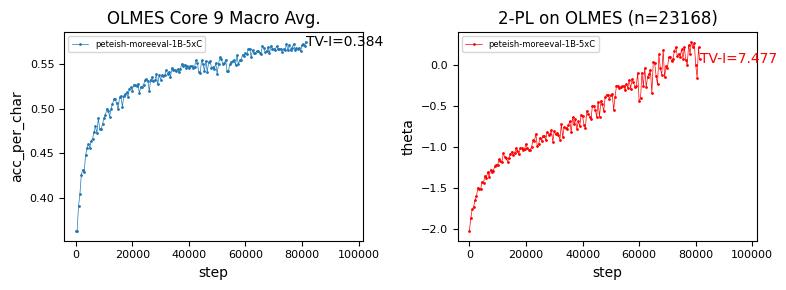

In [177]:
from stats import calculate_and_plot_total_variation, compute_total_variation

N_COLS = 1
N_ROWS = 2
fig, axes = plt.subplots(N_COLS, N_ROWS, figsize=(4*N_ROWS, 3*N_COLS), squeeze=False)

ax = [axes[0, 0]] if axes is not None else None
tv, _ = compute_total_variation(
    df_benchmarks, models=['peteish-moreeval-1B-5xC'], metric='acc_per_char', tasks=[selected_tasks], axes=ax
)
# tv_primary = tv[task]['total_variation'] if not isinstance(task, list) else tv.loc['total_variation']['aggregate']
ax[0].set_title('OLMES Core 9 Macro Avg.')
ax[0].legend(fontsize=6)

ax = axes[0, 1] if axes is not None else None
calculate_and_plot_total_variation(
    x=steps,
    y=thetas,
    metric='theta',
    model_name='peteish-moreeval-1B-5xC',
    color='red',
    title=f'2-PL on OLMES (n={scores.shape[1]})',
    ax=ax,
)
ax.legend(fontsize=6)

fig.tight_layout()

In [178]:
# TODO: Get some predictability in the house!